Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...
    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.
Reading 0 ... 566999  =      0.000 ...   566.999 secs...
2500 0.27528584003448486
5000 0.1157713234424591
7500 0.07952334731817245
10000 0.052424799650907516
12500 0.04466197267174721
15000 0.04915020242333412

ECG Train: 0.009528124104521658 0.995173759903199
ECG Test : 2.0460510388249826 -0.05265581768970179


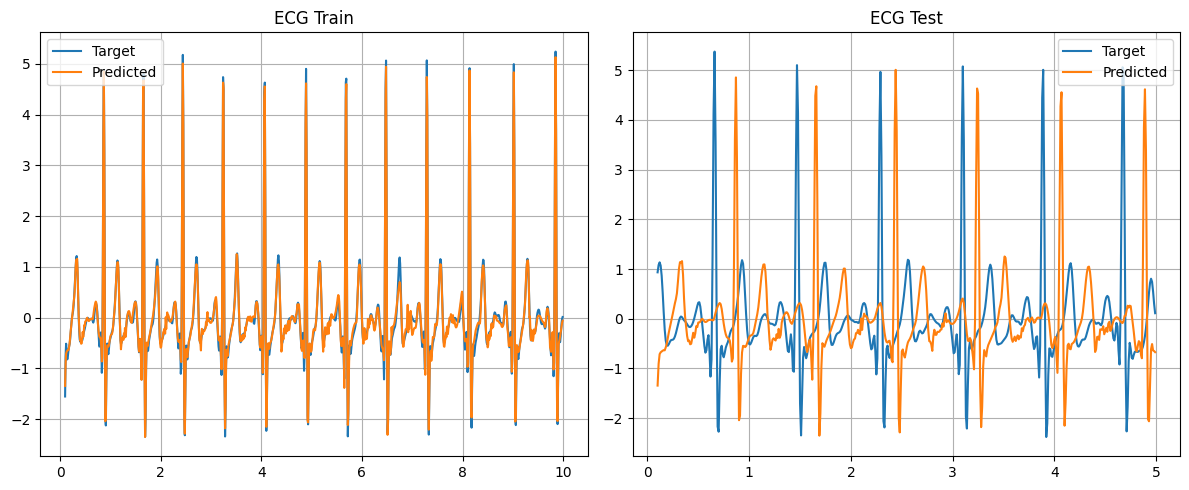

In [7]:

import h5py
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint
import gc
import mne
import time
import sys
import os
from torchdiffeq import odeint

# functions 
def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized

file_raw = '/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif'
raw = mne.io.read_raw_fif(file_raw, preload=True)

mat = loadmat("/home/shobs/Desktop/DDP/scout_id_309.mat")
sc_data = loadmat('/home/shobs/Desktop/DDP/SC_CC120309-27.mat')
sc_matrix = sc_data["sc"]

max_val = np.max(sc_matrix)
Sw_all = (sc_matrix / max_val) * 0.01 if max_val > 0 else sc_matrix
non_zero_indices_per_row = [
    np.nonzero(Sw_all[i, :])[0] for i in range(Sw_all.shape[0])
]

fs_raw = 1000
train_sec = 10
test_sec = 5

start_idx = 2000
train_samples = train_sec * fs_raw
test_samples = test_sec * fs_raw

train_slice = slice(start_idx, start_idx + train_samples)
test_slice  = slice(start_idx + train_samples,
                    start_idx + train_samples + test_samples)

# ECG
ecg_train = -raw[322, train_slice][0][0]
ecg_test  = -raw[322, test_slice][0][0]

# EEG
eeg_train = mat['Value'][:, train_slice]
eeg_test  = mat['Value'][:, test_slice]

# ===============================
# PREPROCESS
# ===============================

ecg_train_processed = preprocess_signal(ecg_train, fs=1000, lowcut=1.5, highcut=20)
ecg_test_processed  = preprocess_signal(ecg_test,  fs=1000, lowcut=1.5, highcut=20)

eeg_train_processed = np.array([
    preprocess_signal(row, fs=1000, lowcut=0.5, highcut=20)
    for row in eeg_train
])

eeg_test_processed = np.array([
    preprocess_signal(row, fs=1000, lowcut=0.5, highcut=20)
    for row in eeg_test
])

# =====================================================
# PREPROCESSING
# =====================================================
def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20):
    detrended = detrend(signal)

    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)

    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized


def simulate_coupled_oscillators(T=4, dt=1/100, alpha=1.0, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1), R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1)

class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.SiLU()
        )
        self.output_layer = nn.Linear(feature_dim, output_dim)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.output_layer(features)
    
    def get_features(self, x):
        return self.feature_extractor(x)
    
# class HeartModel(nn.Module):
#     """A simple MLP to map oscillator states to an ECG signal."""
#     def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, hidden_dim),
#             nn.SiLU(),
#             nn.Linear(hidden_dim, hidden_dim),
#             nn.SiLU(),
#             nn.Dropout(0.1),
#             nn.Linear(hidden_dim, feature_dim),
#             nn.SiLU(),
#             nn.Linear(feature_dim, output_dim)
#         )

#     def forward(self, x):
#         return self.net(x)

def train_heart_model(ecg_signal, device, time_sec):

    model = HeartModel().to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=500
    )

    criterion = nn.MSELoss()

    sim_input = torch.tensor(
        simulate_coupled_oscillators(T=time_sec),
        dtype=torch.float32
    ).to(device)

    target = torch.tensor(
        ecg_signal[::10],
        dtype=torch.float32
    ).unsqueeze(1).to(device)

    losses = []

    for epoch in range(15000):

        pred = model(sim_input)
        loss = criterion(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())

        losses.append(loss.item())

        if (epoch+1) % 2500 == 0:
            print(epoch+1, loss.item())

    return model, losses


# =====================================================
# METRICS
# =====================================================
def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    corr = np.corrcoef(y_true, y_pred)[0,1]
    return mse, corr


# =====================================================
# TRAIN + TEST ECG
# =====================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
fs_model = 100

trained_heart_model, heart_losses = train_heart_model(
    ecg_train_processed,
    device,
    time_sec=10
)

trained_heart_model.eval()


# ---------- TRAIN ----------
with torch.no_grad():
    sim_train = torch.tensor(
        simulate_coupled_oscillators(T=10),
        dtype=torch.float32
    ).to(device)

    ecg_pred_train = (
        trained_heart_model(sim_train)
        .cpu().numpy()
        .flatten()
    )

target_ecg_train = ecg_train_processed[::10]


# ---------- TEST ----------
with torch.no_grad():
    sim_test = torch.tensor(
        simulate_coupled_oscillators(T=5),
        dtype=torch.float32
    ).to(device)

    ecg_pred_test = (
        trained_heart_model(sim_test)
        .cpu().numpy()
        .flatten()
    )

target_ecg_test = ecg_test_processed[::10]


# =====================================================
# PERFORMANCE
# =====================================================
ignore_sec = 0.1
ignore_samples = int(ignore_sec * fs_model)

mse_train, corr_train = metrics(
    target_ecg_train[ignore_samples:],
    ecg_pred_train[ignore_samples:]
)

mse_test, corr_test = metrics(
    target_ecg_test[ignore_samples:],
    ecg_pred_test[ignore_samples:]
)

print("\nECG Train:", mse_train, corr_train)
print("ECG Test :", mse_test, corr_test)


# =====================================================
# PLOTS
# =====================================================
t_train = np.arange(0,10,1/fs_model)
t_test  = np.arange(0,5,1/fs_model)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(t_train[ignore_samples:], target_ecg_train[ignore_samples:], label="Target")
plt.plot(t_train[ignore_samples:], ecg_pred_train[ignore_samples:], label="Predicted")
plt.title("ECG Train")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t_test[ignore_samples:], target_ecg_test[ignore_samples:], label="Target")
plt.plot(t_test[ignore_samples:], ecg_pred_test[ignore_samples:], label="Predicted")
plt.title("ECG Test")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

--- Using device: cuda ---
Total ECG samples: 10000
Train samples: 7000 (duration: 70.00s, t_train len: 7000)
Test samples: 3000 (duration: 30.00s, t_test len: 3000)
Total duration actual: 100.00s

--- Starting Heart Model Training ---
Epoch 1000/25000, Loss: 0.661665
  Test Loss: 1.312085
Epoch 2000/25000, Loss: 0.412931
  Test Loss: 1.427171
Epoch 3000/25000, Loss: 0.300501
  Test Loss: 1.516822
Epoch 4000/25000, Loss: 0.242707
  Test Loss: 1.495272
Epoch 5000/25000, Loss: 0.198263
  Test Loss: 1.561936
Epoch 6000/25000, Loss: 0.166766
  Test Loss: 1.605965
Epoch 7000/25000, Loss: 0.145076
  Test Loss: 1.599175
Epoch 8000/25000, Loss: 0.134615
  Test Loss: 1.625199
Epoch 9000/25000, Loss: 0.118125
  Test Loss: 1.663044
Epoch 10000/25000, Loss: 0.115841
  Test Loss: 1.640373
Epoch 11000/25000, Loss: 0.107384
  Test Loss: 1.659623
Epoch 12000/25000, Loss: 0.098765
  Test Loss: 1.639603
Epoch 13000/25000, Loss: 0.099664
  Test Loss: 1.655483
Epoch 14000/25000, Loss: 0.093068
  Test Loss

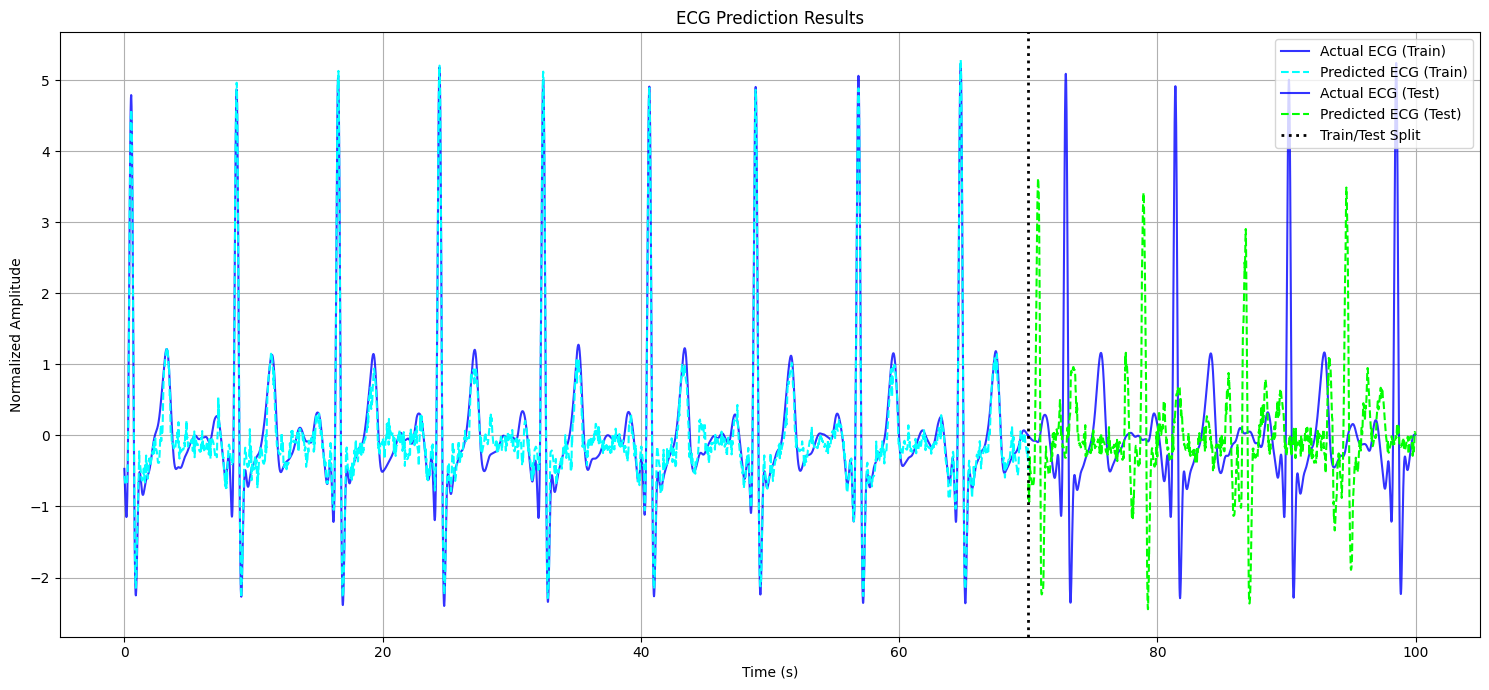

In [ ]:
def simulate_coupled_oscillators(T=4, dt=1/128, alpha=1.0, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=np.pi, n=1.0):
    """
    Simulates two coupled Stuart-Landau oscillators to generate a synthetic input signal.
    """
    N = int(np.round(T / dt))
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    # Pre-allocate arrays
    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # Calculate coupling terms
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        # Update amplitudes (r) and phases (phi)
        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21
        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        # Euler integration step
        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    # Return the state variables of the oscillators
    return np.stack((R1 * np.cos(Phi1), R1 * np.sin(Phi1), R2 * np.cos(Phi2), R2 * np.sin(Phi2)), axis=1)

# --- PyTorch Heart Model ---

class HeartModel(nn.Module):
    """A simple MLP to map oscillator states to an ECG signal."""
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feature_dim),
            nn.SiLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


if __name__ == '__main__':
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"--- Using device: {device} ---")

    # 1. Load and prepare data
    ecg_processed = ecg_train_processed  
    fs = 100 # Use the sampling frequency from earlier in the notebook
    total_samples_available = len(ecg_processed)
    total_duration_actual = total_samples_available / fs

    train_split_ratio = 0.7 # 80% for training, 20% for testing
    train_samples = int(total_samples_available * train_split_ratio)
    test_samples = total_samples_available - train_samples

    train_duration = train_samples / fs
    total_duration = total_duration_actual # Use the actual duration of the available data

    # Time vectors for plotting
    t_full = np.arange(0, total_duration, 1/fs)[:total_samples_available] # Ensure t_full matches actual samples
    t_train = t_full[:train_samples]
    t_test = t_full[train_samples:train_samples + test_samples]

    # 2. Split data into training and testing sets
    ecg_train = ecg_processed[:train_samples].copy()
    ecg_test = ecg_processed[train_samples:train_samples + test_samples].copy()

    # Validate lengths
    print(f"Total ECG samples: {total_samples_available}")
    print(f"Train samples: {len(ecg_train)} (duration: {train_duration:.2f}s, t_train len: {len(t_train)})")
    print(f"Test samples: {len(ecg_test)} (duration: {test_samples/fs:.2f}s, t_test len: {len(t_test)})")
    print(f"Total duration actual: {total_duration_actual:.2f}s")

    # 3. Initialize model, optimizer, and loss function
    # use plateau learning rate scheduler to reduce LR if loss doesn't improve for 500 epochs

    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.MSELoss()

    # 4. Prepare training data
    # Generate synthetic oscillator data ONLY for the training duration
    sim_osc_input_total = torch.tensor(
        simulate_coupled_oscillators(T=total_duration, dt=1/fs),
        dtype=torch.float32
    ).to(device)
    sim_osc_input_train = sim_osc_input_total[:train_samples]
    sim_osc_input_test  = sim_osc_input_total[train_samples:]
    # The actual ECG signal is the target
    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).to(device).unsqueeze(1)

    # 5. Training loop
    print("\n--- Starting Heart Model Training ---")
    num_epochs = 25000
    for epoch in range(num_epochs):
        heart_model.train()

        # Forward pass
        predicted_ecg = heart_model(sim_osc_input_train)
        loss = criterion(predicted_ecg, ecg_target_train)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")
            # print test loss every 1000 epochs
            with torch.no_grad():
                predicted_ecg_test = heart_model(sim_osc_input_test)
                ecg_target_test = torch.tensor(ecg_test, dtype=torch.float32).to(device).unsqueeze(1)
                test_loss = criterion(predicted_ecg_test, ecg_target_test)
                print(f"  Test Loss: {test_loss.item():.6f}")
    print("--- Heart Model Training Finished ---\n")

    # 6. Evaluation and Prediction
    print("--- Generating Final Predictions ---")
    heart_model.eval()
    with torch.no_grad():
        # Generate synthetic oscillator data for the FULL duration (train + test)


        # Predict the ECG for the full duration
        predicted_ecg_full = heart_model(sim_osc_input_total).cpu().numpy().flatten()

        # Split predictions for plotting
        pred_ecg_train = predicted_ecg_full[:train_samples]
        pred_ecg_test = predicted_ecg_full[train_samples:train_samples + test_samples] # Ensure test part matches

    # 7. Plotting Results
    plt.figure(figsize=(15, 7))

    # Plot training data and predictions
    plt.plot(t_train, ecg_train, label='Actual ECG (Train)', color='blue', alpha=0.8)
    plt.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='cyan', linestyle='--')

    # Plot testing data and predictions
    plt.plot(t_test, ecg_test, label='Actual ECG (Test)', color='blue', alpha=0.8)
    plt.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='lime', linestyle='--')

    # Add a vertical line to separate train and test regions
    plt.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')

    criterion = nn.MSELoss()


    plt.title('ECG Prediction Results')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Using device: cuda
Epoch 1000 | Train: 0.340652 | Test: 1.056476
Epoch 2000 | Train: 0.297184 | Test: 1.121393
Epoch 3000 | Train: 0.291201 | Test: 1.104551
Epoch 4000 | Train: 0.288575 | Test: 1.112029
Epoch 5000 | Train: 0.285978 | Test: 1.112723
Epoch 6000 | Train: 0.284517 | Test: 1.116584
Epoch 7000 | Train: 0.283751 | Test: 1.115415
Epoch 8000 | Train: 0.283133 | Test: 1.112964
Epoch 9000 | Train: 0.282714 | Test: 1.103225
Epoch 10000 | Train: 0.282517 | Test: 1.092431
Epoch 11000 | Train: 0.282503 | Test: 1.088182
Epoch 12000 | Train: 0.282374 | Test: 1.083848
Epoch 13000 | Train: 0.282329 | Test: 1.082845
Epoch 14000 | Train: 0.282294 | Test: 1.083449
Epoch 15000 | Train: 0.282252 | Test: 1.084354
Epoch 16000 | Train: 0.282262 | Test: 1.085702
Epoch 17000 | Train: 0.282172 | Test: 1.087352
Epoch 18000 | Train: 0.282208 | Test: 1.087083
Epoch 19000 | Train: 0.282180 | Test: 1.091146
Epoch 20000 | Train: 0.282092 | Test: 1.090312


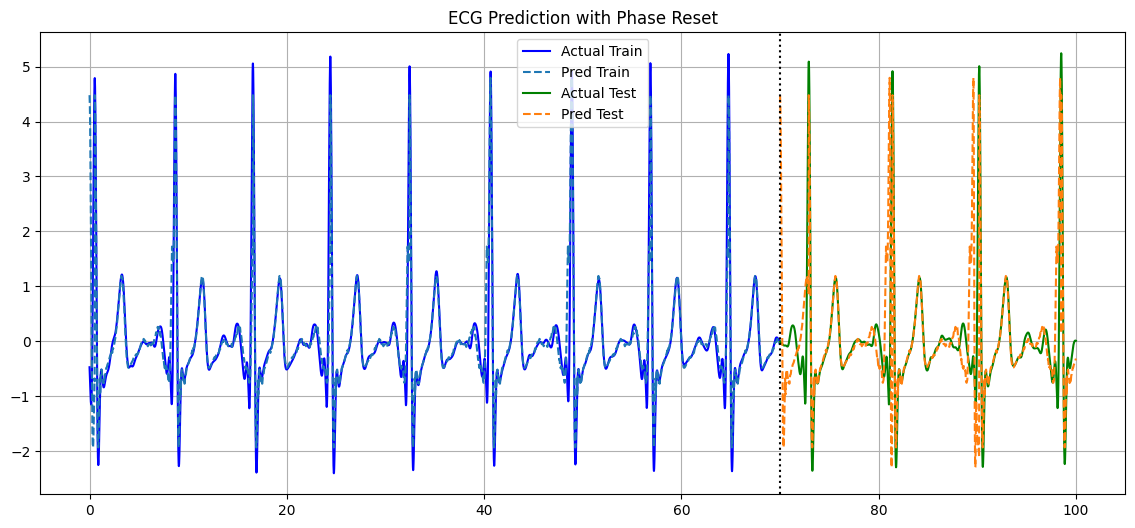

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


def detect_r_peaks(ecg, fs):
    peaks, _ = find_peaks(ecg, height=2.0, distance=int(0.4 * fs))
    return peaks


# --------------------------------------------------
# COUPLED OSCILLATOR WITH PHASE RESET
# --------------------------------------------------

def simulate_with_phase_reset(T, dt, r_peaks_indices,
                              alpha=1.0,
                              omega1=5.01,
                              omega2=5.1,
                              A_init=0.0001,
                              theta_init=np.pi,
                              n=1.0):

    N = int(np.round(T / dt))

    r1, r2 = 1.0, 1.0
    phi1, phi2 = 0.0, 0.0

    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    r_peaks_set = set(r_peaks_indices)

    for i in range(N):

        # ----- HARD PHASE RESET -----
        if i in r_peaks_set:
            phi1 = 0.0
            phi2 = 0.0

        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21

        dphi1 = omega1 + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1),
                     R1*np.sin(Phi1),
                     R2*np.cos(Phi2),
                     R2*np.sin(Phi2)), axis=1)


# --------------------------------------------------
# HEART MODEL
# --------------------------------------------------

class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, feature_dim=32, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, feature_dim),
            nn.SiLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


# --------------------------------------------------
# MAIN EXECUTION
# --------------------------------------------------

if __name__ == '__main__':

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # ---------------------------------
    # Assume ecg_train_processed exists
    # ---------------------------------

    ecg_processed = ecg_train_processed
    fs = 100

    total_samples = len(ecg_processed)
    train_split_ratio = 0.7
    train_samples = int(total_samples * train_split_ratio)
    test_samples = total_samples - train_samples

    ecg_train = ecg_processed[:train_samples]
    ecg_test  = ecg_processed[train_samples:]

    train_duration = train_samples / fs
    test_duration  = test_samples / fs

    # ---------------------------------
    # Detect R-peaks
    # ---------------------------------

    r_peaks_train = detect_r_peaks(ecg_train, fs)
    r_peaks_test  = detect_r_peaks(ecg_test, fs)

    # ---------------------------------
    # Generate phase-locked oscillator
    # ---------------------------------

    sim_train = simulate_with_phase_reset(
        T=train_duration,
        dt=1/fs,
        r_peaks_indices=r_peaks_train
    )

    sim_test = simulate_with_phase_reset(
        T=test_duration,
        dt=1/fs,
        r_peaks_indices=r_peaks_test
    )

    sim_train = torch.tensor(sim_train, dtype=torch.float32).to(device)
    sim_test  = torch.tensor(sim_test, dtype=torch.float32).to(device)

    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)
    ecg_target_test  = torch.tensor(ecg_test, dtype=torch.float32).unsqueeze(1).to(device)

    # ---------------------------------
    # Initialize model
    # ---------------------------------

    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.MSELoss()

    # ---------------------------------
    # Training
    # ---------------------------------

    num_epochs = 20000

    for epoch in range(num_epochs):

        heart_model.train()
        pred_train = heart_model(sim_train)
        loss = criterion(pred_train, ecg_target_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            heart_model.eval()
            with torch.no_grad():
                pred_test = heart_model(sim_test)
                test_loss = criterion(pred_test, ecg_target_test)

            print(f"Epoch {epoch+1} | Train: {loss.item():.6f} | Test: {test_loss.item():.6f}")

    # ---------------------------------
    # Evaluation
    # ---------------------------------

    heart_model.eval()
    with torch.no_grad():
        pred_train = heart_model(sim_train).cpu().numpy().flatten()
        pred_test  = heart_model(sim_test).cpu().numpy().flatten()

    # ---------------------------------
    # Plot
    # ---------------------------------

    t_train = np.arange(0, train_duration, 1/fs)
    t_test  = np.arange(0, test_duration, 1/fs)

    plt.figure(figsize=(14,6))

    plt.plot(t_train, ecg_train, label="Actual Train", color="blue")
    plt.plot(t_train, pred_train, label="Pred Train", linestyle="--")

    plt.plot(t_test + train_duration, ecg_test, label="Actual Test", color="green")
    plt.plot(t_test + train_duration, pred_test, label="Pred Test", linestyle="--")

    plt.axvline(x=train_duration, linestyle=":", color="black")

    plt.legend()
    plt.grid(True)
    plt.title("ECG Prediction with Phase Reset")
    plt.show()

In [20]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


# --------------------------------------------------
# R-PEAK DETECTION
# --------------------------------------------------

def detect_r_peaks(ecg, fs):
    peaks, _ = find_peaks(ecg, height=2.0, distance=int(0.4 * fs))
    return peaks


# --------------------------------------------------
# ECG PHASE COMPUTATION (0 → 2π between beats)
# --------------------------------------------------

def compute_ecg_phase(ecg, fs):
    peaks = detect_r_peaks(ecg, fs)
    phase = np.zeros(len(ecg))

    for i in range(len(peaks) - 1):
        start = peaks[i]
        end = peaks[i + 1]
        phase[start:end] = np.linspace(0, 2*np.pi, end - start)

    return phase


# --------------------------------------------------
# COUPLED OSCILLATOR WITH SOFT PHASE LOCK (PLL)
# --------------------------------------------------

def simulate_with_pll(T, dt, ecg_phase,
                      alpha=1.0,
                      omega1=0.782,
                      omega2=0.795,
                      A_init=0.0001,
                      theta_init=np.pi,
                      n=1.0,
                      k=1.0):   # phase locking strength

    N = int(np.round(T / dt))

    r1, r2 = 1.0, 1.0
    phi1, phi2 = 0.0, 0.0

    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

    for i in range(N):

        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        # ECG phase at this timestep
        phi_ecg = ecg_phase[i]

        # Phase error (bounded, smooth)
        phase_error1 = np.sin(phi_ecg - phi1)
        phase_error2 = np.sin(phi_ecg - phi2)

        # Coupling between oscillators
        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        dr1 = alpha * r1 - r1**3 + coupling12
        dr2 = alpha * r2 - r2**3 + coupling21

        # ---- PLL correction added here ----
        dphi1 = omega1 + k * phase_error1 \
                + A12 * r2 / (r1 + 1e-9) * np.sin(theta12 + n * (phi2 - phi1))

        dphi2 = omega2 + k * phase_error2 \
                + A21 * r1 / (r2 + 1e-9) * np.sin(theta21 + n * (phi1 - phi2))

        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1),
                     R1*np.sin(Phi1),
                     R2*np.cos(Phi2),
                     R2*np.sin(Phi2)), axis=1)


# --------------------------------------------------
# HEART MODEL
# --------------------------------------------------

class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, feature_dim=32, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, feature_dim),
            nn.SiLU(),
            nn.Linear(feature_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


# --------------------------------------------------
# MAIN EXECUTION
# --------------------------------------------------

if __name__ == '__main__':

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    ecg_processed = ecg_train_processed
    fs = 100

    total_samples = len(ecg_processed)
    train_ratio = 0.7
    train_samples = int(total_samples * train_ratio)
    test_samples = total_samples - train_samples

    ecg_train = ecg_processed[:train_samples]
    ecg_test  = ecg_processed[train_samples:]

    train_duration = train_samples / fs
    test_duration  = test_samples / fs

    # ---------------------------------
    # Compute ECG phase for train/test
    # ---------------------------------

    phase_train = compute_ecg_phase(ecg_train, fs)
    phase_test  = compute_ecg_phase(ecg_test, fs)

    # ---------------------------------
    # Generate PLL-synchronized oscillator
    # ---------------------------------

    sim_train = simulate_with_pll(
        T=train_duration,
        dt=1/fs,
        ecg_phase=phase_train,
        k=0.5   # try 0.5–2.0
    )

    sim_test = simulate_with_pll(
        T=test_duration,
        dt=1/fs,
        ecg_phase=phase_test,
        k=1.0
    )

    sim_train = torch.tensor(sim_train, dtype=torch.float32).to(device)
    sim_test  = torch.tensor(sim_test, dtype=torch.float32).to(device)

    ecg_target_train = torch.tensor(ecg_train, dtype=torch.float32).unsqueeze(1).to(device)
    ecg_target_test  = torch.tensor(ecg_test, dtype=torch.float32).unsqueeze(1).to(device)

    # ---------------------------------
    # Model
    # ---------------------------------

    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.MSELoss()

    # ---------------------------------
    # Training
    # ---------------------------------

    num_epochs = 2000

    for epoch in range(num_epochs):

        heart_model.train()
        pred_train = heart_model(sim_train)
        loss = criterion(pred_train, ecg_target_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 1000 == 0:
            heart_model.eval()
            with torch.no_grad():
                pred_test = heart_model(sim_test)
                test_loss = criterion(pred_test, ecg_target_test)

            print(f"Epoch {epoch+1} | Train: {loss.item():.6f} | Test: {test_loss.item():.6f}")

    # ---------------------------------
    # Evaluation
    # ---------------------------------

    heart_model.eval()
    with torch.no_grad():
        pred_train = heart_model(sim_train).cpu().numpy().flatten()
        pred_test  = heart_model(sim_test).cpu().numpy().flatten()

    # ---------------------------------
    # Plot
    # ---------------------------------

    t_train = np.arange(0, train_duration, 1/fs)
    t_test  = np.arange(0, test_duration, 1/fs)

    plt.figure(figsize=(14,6))

    plt.plot(t_train, ecg_train, label="Actual Train", color="blue")
    plt.plot(t_train, pred_train, linestyle="--")

    plt.plot(t_test + train_duration, ecg_test, label="Actual Test", color="green")
    plt.plot(t_test + train_duration, pred_test, linestyle="--")

    plt.axvline(x=train_duration, linestyle=":", color="black")

    plt.legend()
    plt.grid(True)
    plt.title("ECG Prediction with Soft Phase Lock (PLL)")
    plt.show()

Using device: cuda


AcceleratorError: CUDA error: unspecified launch failure
Search for `cudaErrorLaunchFailure' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
